In [9]:
import os, sys
sys.path.append(os.path.join(os.environ.get('IDEFIX_DIR','../../../../'), 'pytools'))
import numpy as np
import matplotlib.pyplot as plt
import dump_io as io

import pickle as pk
from astropy import constants as const

with open('units.pk', 'rb') as f: units = pk.load(f)

In [10]:
dirc = 'out/'

def load(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer][0]

In [11]:
dmp = io.readDump(f'{dirc}/dump.0000.dmp')
r  = dmp.x1
dr = dmp.x1r - dmp.x1l

mu = 2.353
gamma = 1.4

aR = (4*const.sigma_sb/const.c).to_value(units['radiation_alpha'])
rho0 = 1
prs0 = 1
Er0 = aR * (mu*prs0/rho0) ** 4

kappa = 0.1 / units['opacity'].to_value('cm2/g')
lam = 1./3.
c   = const.c.to_value(units['velocity'])
tau0 = 0.0

r1 = r[0] - 0.5*dr[0]
r2 = r[-1] + 0.5*dr[-1]

#recalculate for S(r)
L = 6.73e-3*const.L_sun.to_value(units['power'])
factor_A = (1 - np.exp(-kappa*rho0*dr)) * L / (4*np.pi*dr) * np.exp(kappa*rho0*(r1+dr/2)-tau0)
factor_a = factor_A / (c*lam)

S = factor_A * np.exp(-kappa*rho0*r) / r**2

from scipy.special import expi as Ei

c1 = -factor_a * np.exp(-kappa*rho0*r2)
c2 = Er0 + c1/r1 + factor_a * (kappa*rho0*Ei(-kappa*rho0*r1) + np.exp(-kappa*rho0*r1)/r1)
Ean = -factor_a * (kappa*rho0*Ei(-kappa*rho0*r) + np.exp(-kappa*rho0*r)/r) - c1/r + c2

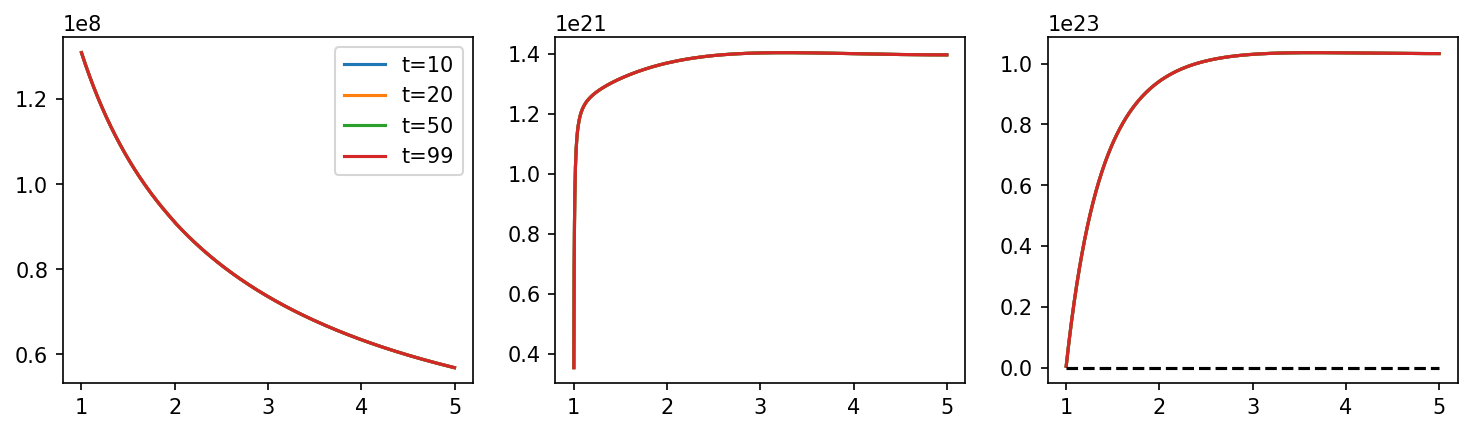

In [12]:
fig, ax = plt.subplots(ncols=3, dpi=150, figsize=(12,3))

for idx, i in enumerate([10, 20, 50, 99]):
    c = f'C{idx}'
    try: rho = load(i=i, var='Vc-RHO')
    except FileNotFoundError: continue
    prs = load(i=i, var='Vc-PRS')
    tmp = mu * prs / rho
    Er  = load(i=i, var='ERAD')
    ax[0].plot(r, prs[0]/prs0, c=c, label=f't={i}')
    ax[1].plot(r, Er[0] / Ean - 1, c=c)
    ax[2].plot(r, Er[0] / Er0, c=c)
    
ax[2].plot(r, Ean/Er0, ls='--', c='k')
# ax[1].plot(x, 1+x, ls='--', c='k')
# ax[1].set_ylim(0, 20000)
ax[0].legend()
plt.show()